In [ ]:
# RentWise: House Rent Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
## 1. Data Loading

In [2]:
df = pd.read_csv("C:/Users/saisr/Downloads/archive/House_Rent_Dataset.csv")

df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 296.7+ KB


Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [ ]:
## 2. Data Cleaning

In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['posted_on', 'bhk', 'rent', 'size', 'floor', 'area_type',
       'area_locality', 'city', 'furnishing_status', 'tenant_preferred',
       'bathroom', 'point_of_contact'],
      dtype='object')

In [5]:
df.drop(columns=['point_of_contact'], inplace=True)

df.columns

Index(['posted_on', 'bhk', 'rent', 'size', 'floor', 'area_type',
       'area_locality', 'city', 'furnishing_status', 'tenant_preferred',
       'bathroom'],
      dtype='object')

In [6]:
df.rename(columns={
    'bhk': 'bedrooms',
    'size': 'sqft',
    'bathroom': 'bathrooms'
}, inplace=True)

df.columns

Index(['posted_on', 'bedrooms', 'rent', 'sqft', 'floor', 'area_type',
       'area_locality', 'city', 'furnishing_status', 'tenant_preferred',
       'bathrooms'],
      dtype='object')

In [7]:
def get_floor(x):
    if "Ground" in str(x):
        return 0
    try:
        return int(str(x).split(" ")[0])
    except:
        return None

df['floor_num'] = df['floor'].apply(get_floor)

df[['floor', 'floor_num']].head()

,floor,floor_num
0,Ground out of 2,0.0
1,1 out of 3,1.0
2,1 out of 3,1.0
3,1 out of 2,1.0
4,1 out of 2,1.0


In [8]:
df.isnull().sum()

posted_on             0
bedrooms              0
rent                  0
sqft                  0
floor                 0
area_type             0
area_locality         0
city                  0
furnishing_status     0
tenant_preferred      0
bathrooms             0
floor_num            34
dtype: int64

In [9]:
df = df.dropna()

In [ ]:
## 3. Feature Engineering

In [10]:
df.isnull().sum()

posted_on            0
bedrooms             0
rent                 0
sqft                 0
floor                0
area_type            0
area_locality        0
city                 0
furnishing_status    0
tenant_preferred     0
bathrooms            0
floor_num            0
dtype: int64

In [ ]:
## 4. Exploratory Data Analysis

In [11]:
df_model = df.copy()

df_model = df_model.drop(columns=['posted_on', 'floor', 'area_locality'])

df_encoded = pd.get_dummies(df_model, drop_first=True)

In [ ]:
## 5. Model Building

In [12]:
import numpy as np

X = df_encoded.drop(columns=['rent'])
y = np.log(df_encoded['rent'])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=20, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

In [ ]:
## 6. Model Evaluation

In [15]:
predictions = rf_model.predict(X_test)

predictions_exp = np.exp(predictions)
y_test_exp = np.exp(y_test)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_exp, predictions_exp))
print("Final RMSE:", rmse)

Final RMSE: 26675.716195788533


In [16]:
import pandas as pd

importance = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(10)

bathrooms                            0.330689
city_Mumbai                          0.269808
sqft                                 0.208934
bedrooms                             0.054190
floor_num                            0.043540
city_Delhi                           0.015895
furnishing_status_Unfurnished        0.013529
city_Hyderabad                       0.009562
furnishing_status_Semi-Furnished     0.009527
tenant_preferred_Bachelors/Family    0.009195
dtype: float64

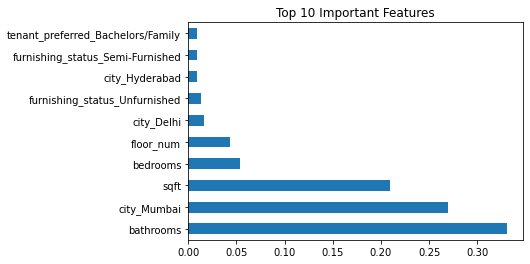

In [17]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
## 8. Key Insights
1. Bathrooms are the strongest driver of rent
Properties with more bathrooms tend to have significantly higher rental prices.
This suggests that amenities and comfort features influence rent more than basic room count.
2. Location plays a major role (especially Mumbai)
Properties in Mumbai have substantially higher rent compared to other cities.
This highlights the strong impact of urban demand and economic activity on housing prices.
3. Property size (sqft) strongly influences rent
Larger properties consistently command higher rental values.
This confirms that space is a key pricing factor in rental markets.
4. Bedrooms have less impact than expected
While more bedrooms increase rent, their impact is lower than bathrooms and size.
This indicates that quality and usability of space matter more than quantity of rooms.
5. Floor level has moderate influence
Higher floors slightly affect rent, but not as strongly as other features.
This suggests floor preference is secondary compared to location and amenities.
6. Furnishing status affects pricing
Furnished and semi-furnished properties generally have higher rent than unfurnished ones.
This reflects the added value of ready-to-move-in homes.
7. Tenant preference has minimal impact
Whether a property is listed for families or bachelors has relatively low influence on rent.
Indicates that market demand outweighs tenant restrictions.